# Tech Challenge — Fase 3
## Assistente Médico com PubMedQA, Fine-tuning, LangChain e LangGraph

Este notebook implementa um protótipo acadêmico de assistente biomédico usando **dados reais do PubMedQA (PQA-L)**.

### Escopo
- carregar e preparar o PubMedQA;
- fazer curadoria/preprocessing;
- realizar fine-tuning de uma LLM com LoRA;
- avaliar respostas `yes / no / maybe`;
- integrar o modelo ao LangChain;
- consultar uma base estruturada derivada do próprio PubMedQA, indexada por PMID;
- orquestrar segurança → recuperação → geração → auditoria com LangGraph;
- registrar logs e apresentar a fonte (PMID).

> **Uso acadêmico.** PubMedQA contém perguntas de pesquisa biomédica baseadas em publicações do PubMed. Ele não equivale a prontuários ou protocolos internos de um hospital e este protótipo não deve ser usado para diagnóstico ou prescrição.

**Como acompanhar:** sigo da preparação dos dados até o treino, a avaliação e a demonstração do assistente. Os comentários destacam o motivo das escolhas e o que conferir nas saídas. No item de LangChain, a integração desta versão se limita à construção e demonstração do template; a inferência usa uma função própria, como detalhado adiante.


## 1. Relação com o Tech Challenge

O desafio pede fine-tuning de LLM com conteúdo médico, integração com LangChain, consultas estruturadas, contextualização, segurança, logging, explainability, LangGraph e avaliação.

Como o enunciado sugere o **PubMedQA**, este projeto o utiliza como fonte pública para demonstrar a arquitetura. A adaptação acadêmica é importante: em vez de inventar prontuários, a “base estruturada” é formada exclusivamente pelos registros reais do PQA-L e o contexto é o abstract associado ao PMID.

Em um cenário hospitalar real, essa camada seria substituída por dados internos devidamente anonimizados e governados.

In [1]:
# 2. Configuração
from pathlib import Path
import os, re, json, random, logging
import numpy as np
import pandas as pd

# Fixo a seed para conseguir repetir a divisão dos dados e comparar as execuções.
# Ainda assim, posso encontrar pequenas diferenças ao mudar de GPU ou ambiente.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Guardo os arquivos gerados em artifacts para deixar os resultados organizados.
# Se estiver no Colab, preciso salvar essa pasta antes de encerrar a sessão.
BASE = Path.cwd()
ARTIFACTS = BASE / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
OUTPUT_DIR = ARTIFACTS / "tinyllama_pubmedqa_lora"

# Para validar rapidamente o notebook:
SMOKE_MODE = False

# Mude para True quando estiver em ambiente com GPU e quiser treinar.
RUN_FINE_TUNING = True

# Uso o smoke mode quando quero testar o pipeline com poucos exemplos.
# Aqui, deixei o modo completo e o treinamento habilitados.
TRAIN_SAMPLES = 60 if SMOKE_MODE else 450
VAL_SAMPLES = 20 if SMOKE_MODE else 50
TEST_SAMPLES = 30 if SMOKE_MODE else 500

print("Modelo:", MODEL_NAME)
print("Smoke mode:", SMOKE_MODE)
print("Executar fine-tuning:", RUN_FINE_TUNING)

Modelo: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Smoke mode: False
Executar fine-tuning: True


## 3. Dependências

Em Google Colab, executamos as células abaixo. Para execução local, deve-se usar `requirements.txt` incluído no ZIP.


In [2]:
# Instalo as bibliotecas que vou usar ao longo do notebook. Como nem todas têm
# a versão fixada, confiro as versões abaixo para registrar o ambiente do teste.
%pip install -q \
    "pandas==2.2.3" \
    datasets \
    transformers \
    peft \
    accelerate \
    sentencepiece \
    scikit-learn \
    matplotlib \
    langchain-core \
    langgraph

# Removo também o torchao do ambiente. Esta linha faz parte da preparação
# das dependências; o modelo abaixo não está configurado para usar quantização.
%pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [3]:
# 4. Imports
# Reúno aqui as bibliotecas para preparar os dados, treinar e avaliar o modelo.
# Importo LangChain e LangGraph mais adiante, perto de onde vou usá-los.
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, PeftModel

In [4]:
import torch
import transformers
import peft

# Confiro as versões e se o PyTorch reconheceu a GPU.
# Essas informações me ajudam a documentar em qual ambiente rodei o experimento.
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
PEFT: 0.20.0
CUDA: True
GPU: Tesla T4


## 5. Carregamento do PubMedQA

Usamos apenas a configuração **`pqa_labeled`**, composta por exemplos com decisão final anotada. Não usamos `pqa_artificial` e não geramos exemplos artificiais.

In [5]:
# Carrego a base anotada do PubMedQA. Apesar do nome train no Hugging Face,
# ainda vou separar esses registros em treino, validação e teste.
raw = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
print(raw)
print(raw.column_names)
# Olho um exemplo antes de tratar os dados para entender como a pergunta,
# os parágrafos do contexto e a resposta de referência estão organizados.
raw[0]

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
    num_rows: 1000
})
['pubid', 'question', 'context', 'long_answer', 'final_decision']


{'pubid': 21645374,
 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?',
 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.',
   'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), ce

In [7]:
# 6. Preprocessing e curadoria
# Faço uma limpeza simples de espaços e trato os valores ausentes.
# A ideia é padronizar o texto, sem reescrever o conteúdo biomédico.
def clean_text(value):
    if value is None:
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def convert_record(row):
    ctx = row.get("context", {}) or {}
    paragraphs = ctx.get("contexts", []) or []
    labels = ctx.get("labels", []) or []

    # Mantém a estrutura textual do abstract quando houver labels.
    structured_parts = []
    for i, paragraph in enumerate(paragraphs):
        label = labels[i] if i < len(labels) else "CONTEXT"
        structured_parts.append(f"{clean_text(label)}: {clean_text(paragraph)}")

    return {
        "pubid": clean_text(row.get("pubid")),
        "question": clean_text(row.get("question")),
        "context": "\n".join(structured_parts),
        "long_answer": clean_text(row.get("long_answer")),
        "label": clean_text(row.get("final_decision")).lower(),
    }

df = pd.DataFrame([convert_record(r) for r in raw])

# Retiro os registros sem os campos necessários e mantenho um exemplo por PMID.
# Assim, evito colocar o mesmo identificador em conjuntos diferentes depois.
valid_labels = {"yes", "no", "maybe"}
df = df[
    df["label"].isin(valid_labels)
    & df["question"].ne("")
    & df["context"].ne("")
    & df["pubid"].ne("")
].drop_duplicates(subset=["pubid"]).reset_index(drop=True)

# Confiro quantos registros sobraram e como as classes estão distribuídas.
# Isso ajuda a perceber se o modelo vai encontrar muito mais exemplos de uma classe.
print("Registros após curadoria:", len(df))
display(df.head(3))
print(df["label"].value_counts())

Registros após curadoria: 1000


,pubid,question,context,long_answer,label
0,21645374,Do mitochondria play a role in remodelling lac...,BACKGROUND: Programmed cell death (PCD) is the...,Results depicted mitochondrial dynamics in viv...,yes
1,16418930,Landolt C and snellen e acuity: differences in...,BACKGROUND: Assessment of visual acuity depend...,"Using the charts described, there was only a s...",no
2,9488747,"Syncope during bathing in infants, a pediatric...",BACKGROUND: Apparent life-threatening events i...,"""Aquagenic maladies"" could be a pediatric form...",yes


label
yes      552
no       338
maybe    110
Name: count, dtype: int64


### Sobre anonimização

O PQA-L é um dataset de literatura biomédica associado a publicações/PMIDs, e não um conjunto de prontuários criado neste projeto. Portanto, **não fabricamos dados pessoais para depois anonimizá-los**. A etapa demonstra limpeza, validação de esquema, remoção de duplicatas e curadoria. Em produção hospitalar, a anonimização de dados internos seria uma etapa obrigatória antes do treinamento.

In [8]:
# 7. Divisão dos dados
# Para o modo completo: 450 treino + 50 validação + 500 teste.
# Para smoke mode: subconjuntos menores para testar o pipeline rapidamente.

# Separo os dados de forma estratificada para tentar manter
# a proporção das classes yes, no e maybe em cada conjunto.
# Reservo metade para teste e 10% da metade restante para validação: 450/50/500.
train_pool, test_full = train_test_split(
    df, test_size=0.50, random_state=SEED, stratify=df["label"]
)
train_full, val_full = train_test_split(
    train_pool, test_size=0.10, random_state=SEED, stratify=train_pool["label"]
)

# Para o teste rápido, retiro uma amostra de cada conjunto já separado.
# Assim, continuo sem misturar os exemplos de treino, validação e teste.
def sample_stratified(frame, n):
    if n >= len(frame):
        return frame.copy().reset_index(drop=True)
    sampled, _ = train_test_split(
        frame, train_size=n, random_state=SEED, stratify=frame["label"]
    )
    return sampled.reset_index(drop=True)

train_df = sample_stratified(train_full, min(TRAIN_SAMPLES, len(train_full)))
val_df = sample_stratified(val_full, min(VAL_SAMPLES, len(val_full)))
test_df = sample_stratified(test_full, min(TEST_SAMPLES, len(test_full)))

print("Treino:", len(train_df), "Validação:", len(val_df), "Teste:", len(test_df))

Treino: 450 Validação: 50 Teste: 500


In [9]:
# Confiro se as três classes aparecem em cada conjunto.
# Mesmo mantendo as proporções, ainda tenho poucos exemplos da classe menos frequente.
print("TREINO")
print(train_df["label"].value_counts())

print("\nVALIDAÇÃO")
print(val_df["label"].value_counts())

print("\nTESTE")
print(test_df["label"].value_counts())

TREINO
label
yes      248
no       152
maybe     50
Name: count, dtype: int64

VALIDAÇÃO
label
yes      28
no       17
maybe     5
Name: count, dtype: int64

TESTE
label
yes      276
no       169
maybe     55
Name: count, dtype: int64


In [10]:
# 8. Instruction tuning

# Monto os exemplos com instrução, contexto, pergunta e resposta esperada.
# Uso a decisão e a conclusão da base como alvos no treino e na validação.
# Na hora de gerar uma resposta, deixo esses alvos de fora. Mantenho o inglês da base.
def training_text(row):
    return f'''### Instruction
Answer the biomedical research question using only the supplied PubMedQA context.

Your response must follow exactly this format:
Decision: yes/no/maybe
Explanation: concise evidence-based explanation

Choose exactly one decision among: yes, no, maybe.

### PMID

{row["pubid"]}

### Context

{row["context"]}

### Question

{row["question"]}

### Response

Decision: {row["label"]}
Explanation: {row["long_answer"]}'''


train_hf = Dataset.from_pandas(
    pd.DataFrame({
        "text": [
            training_text(row)
            for _, row in train_df.iterrows()
        ]
    }),
    preserve_index=False
)


val_hf = Dataset.from_pandas(
    pd.DataFrame({
        "text": [
            training_text(row)
            for _, row in val_df.iterrows()
        ]
    }),
    preserve_index=False
)


print("Exemplos de treino:", len(train_hf))
print("Exemplos de validação:", len(val_hf))

# Mostro só o começo de um exemplo para conferir a estrutura que montei.
# A resposta pode ficar fora dessa prévia de 1.800 caracteres.
print("\nExemplo de instruction tuning:\n")
print(train_hf[0]["text"][:1800])

Exemplos de treino: 450
Exemplos de validação: 50

Exemplo de instruction tuning:

### Instruction
Answer the biomedical research question using only the supplied PubMedQA context.

Your response must follow exactly this format:
Decision: yes/no/maybe
Explanation: concise evidence-based explanation

Choose exactly one decision among: yes, no, maybe.

### PMID

21172844

### Context

OBJECTIVE: To determine whether TDP-43 type is associated with distinct patterns of brain atrophy on MRI in subjects with pathologically confirmed frontotemporal lobar degeneration (FTLD).
METHODS: In this case-control study, we identified all subjects with a pathologic diagnosis of FTLD with TDP-43 immunoreactive inclusions (FTLD-TDP) and at least one volumetric head MRI scan (n = 42). In each case we applied published criteria for subclassification of FTLD-TDP into FTLD-TDP types 1-3. Voxel-based morphometry was used to compare subjects with each of the different FTLD-TDP types to age- and gender-matched 

In [11]:
# 9. Tokenizer e modelo
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Uso o token de fim de sequência para preencher os espaços vazios dos lotes
# quando o tokenizer não tem um token próprio para isso.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Carrego o modelo em float16 quando tenho GPU para economizar memória.
# Na CPU, uso float32. Aqui não estou usando quantização em 4 ou 8 bits.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

# Limito a entrada a 512 tokens para controlar o uso de memória.
# Preciso considerar que textos maiores serão cortados e posso perder parte
# do contexto ou até da resposta esperada durante o treino.
MAX_LENGTH = 512

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

tokenized_train = train_hf.map(tokenize, batched=True, remove_columns=["text"])
tokenized_val = val_hf.map(tokenize, batched=True, remove_columns=["text"])

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [12]:
# 10. LoRA / PEFT
# Uso LoRA para treinar adaptações nas camadas de atenção e manter os pesos
# do modelo-base congelados. Com r, defino o tamanho dessas adaptações;
# com alpha, sua escala. O dropout ajuda na regularização durante o treino.
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

model = get_peft_model(model, lora_config)
# Confiro quantos parâmetros vou treinar em relação ao total do modelo.
# Essa saída ajuda a visualizar a economia de usar LoRA.
model.print_trainable_parameters()

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


In [14]:
# 11. Fine-tuning

# Uso um exemplo por lote para caber na memória e acumulo os gradientes
# de quatro passos antes de atualizar os pesos. Em uma GPU, isso reúne
# quatro exemplos por atualização. Com duas épocas, percorro o treino duas vezes.
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    # Treinamento
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,

    # Otimização
    learning_rate=2e-4,

    # Logging
    logging_steps=10,

    # Avaliação
    eval_strategy="steps",
    eval_steps=50,

    # Checkpoints
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,

    # GPU
    fp16=torch.cuda.is_available(),

    # Outras configurações
    report_to="none",
    seed=SEED
)


# Uso mlm=False porque quero treinar a previsão do próximo token.
# Aqui, não separo apenas a resposta para calcular a loss: os tokens
# da instrução e do contexto também entram no objetivo de treinamento.
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=collator
)


if RUN_FINE_TUNING:

    print("=" * 60)
    print("INICIANDO FINE-TUNING")
    print("=" * 60)

    print(f"Exemplos de treino: {len(train_hf)}")
    print(f"Exemplos de validação: {len(val_hf)}")
    print(f"Épocas: {training_args.num_train_epochs}")
    print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")

    train_result = trainer.train()

    print("\n" + "=" * 60)
    print("RESULTADO DO TREINAMENTO")
    print("=" * 60)

    # Olho a loss para acompanhar o erro na previsão dos tokens.
    # Depois, avalio separadamente se o modelo acertou as classes yes/no/maybe.
    print(f"Training loss: {train_result.training_loss:.4f}")

    # Avaliação final no conjunto de validação
    eval_result = trainer.evaluate()

    print("\nResultado da validação:")

    for key, value in eval_result.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    # Salva o adapter LoRA
    # Salvo o adapter LoRA e o tokenizer para poder reutilizar o ajuste.
    # Em outra sessão, preciso carregar o modelo-base e conectar esse adapter.
    model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)

    print("\nAdapter salvo em:", OUTPUT_DIR)

else:

    print(
        "Fine-tuning não executado. "
        "Defina RUN_FINE_TUNING=True em ambiente com GPU."
    )

INICIANDO FINE-TUNING
Exemplos de treino: 450
Exemplos de validação: 50
Épocas: 2
Gradient accumulation: 4


Step,Training Loss,Validation Loss
50,1.315436,1.361833
100,1.369397,1.357317
150,1.339150,1.355383
200,1.330652,1.354789
226,1.287816,1.354694



RESULTADO DO TREINAMENTO
Training loss: 1.3775


Training Loss,Validation Loss,Step
1.287816,1.354694,226



Resultado da validação:
eval_loss: 1.3547

Adapter salvo em: /content/artifacts/tinyllama_pubmedqa_lora


## 12. Avaliação

A métrica principal é a classificação da decisão final em `yes`, `no` ou `maybe`.  
Se `RUN_FINE_TUNING=False`, o resultado abaixo é apenas um **baseline do modelo carregado com o adapter LoRA ainda não treinado**; não deve ser apresentado como resultado de fine-tuning.

Na leitura dos resultados, separo duas perguntas: o parser conseguiu identificar uma classe e essa classe estava certa? A cobertura responde à primeira; a accuracy global, à segunda. As saídas já salvas pertencem à execução original do notebook.


In [16]:
# 12. Avaliação

# Monto aqui a entrada que predict_one realmente envia ao modelo, inclusive
# no LangGraph. Deixo a decisão e a conclusão de referência de fora para não
# entregar a resposta. Este prompt tem uma redação diferente da usada no treino.
def inference_prompt(row):
    return f'''### Instruction
Answer using only the PubMedQA context.
Output first: Decision: yes/no/maybe

### PMID

{row["pubid"]}

### Context

{row["context"]}

### Question

{row["question"]}

### Response

Decision:'''


# Procuro a primeira palavra yes, no ou maybe no texto gerado.
# É uma forma simples de extrair a decisão, mas posso capturar uma palavra
# fora da resposta esperada. Se não encontrar nenhuma, marco como unknown.
def extract_label(text):
    text = text.lower()
    m = re.search(r"\b(yes|no|maybe)\b", text)
    return m.group(1) if m else "unknown"


def predict_one(row, max_new_tokens=80):
    prompt = inference_prompt(row)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Desativo o cálculo de gradientes porque aqui só preciso gerar a resposta.
    # Uso geração sem amostragem e limito a quantidade de tokens novos.
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # Leio apenas a continuação gerada pelo modelo. Se eu incluísse o prompt,
    # poderia capturar o yes/no/maybe da instrução como se fosse a resposta.
    generated = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return extract_label(generated), generated


# ============================================================
# Avaliação no conjunto de teste
# ============================================================

preds = []
generations = []

for _, row in test_df.iterrows():
    pred, generated = predict_one(row)

    preds.append(pred)
    generations.append(generated)


# DataFrame com os resultados
eval_df = test_df[
    ["pubid", "question", "label"]
].copy()

eval_df["prediction"] = preds
eval_df["generation"] = generations


# ============================================================
# Métricas
# ============================================================

# Respostas que seguiram corretamente o formato yes/no/maybe
# Considero válida a saída em que consegui extrair uma das três classes.
# Isso não quer dizer que ela esteja certa ou no formato pedido, então
# olho a cobertura junto com a accuracy global.
valid_eval = eval_df[
    eval_df["prediction"].isin(valid_labels)
]

# Coverage:
# porcentagem de respostas que produziram yes/no/maybe
coverage = len(valid_eval) / len(eval_df)

# Accuracy global:
# respostas "unknown" também são consideradas incorretas
accuracy_all = (
    eval_df["prediction"] == eval_df["label"]
).mean()


print("=" * 60)
print("RESULTADOS DA AVALIAÇÃO")
print("=" * 60)

print(f"\nTotal de exemplos de teste: {len(eval_df)}")

print(
    f"Respostas válidas: "
    f"{len(valid_eval)}/{len(eval_df)}"
)

print(
    f"Cobertura de respostas válidas: "
    f"{coverage:.2%}"
)

print(
    f"Accuracy global: "
    f"{accuracy_all:.4f} ({accuracy_all:.2%})"
)


# ============================================================
# Relatório por classe
# ============================================================

# Olho o recall para ver quantos casos de cada classe o modelo reconheceu
# e a precision para ver quantas previsões daquela classe estavam certas.
# O F1 combina as duas medidas. Uso zero_division=0 para evitar valores
# indefinidos, mas também confiro se alguma classe ficou sem previsões.
print("\nRelatório de classificação:")

print(
    classification_report(
        eval_df["label"],
        eval_df["prediction"],
        labels=["yes", "no", "maybe"],
        zero_division=0
    )
)


# ============================================================
# Distribuição das previsões
# ============================================================

print("\nDistribuição das previsões:")

print(
    eval_df["prediction"]
    .value_counts(dropna=False)
)


# ============================================================
# Primeiros resultados
# ============================================================

# Comparo a resposta gerada com a classe prevista e a referência.
# Assim, consigo observar erros de classificação e problemas no formato,
# já que as métricas não dizem se a explicação ficou boa.
display(
    eval_df[
        [
            "pubid",
            "question",
            "label",
            "prediction",
            "generation"
        ]
    ].head()
)

[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

RESULTADOS DA AVALIAÇÃO

Total de exemplos de teste: 500
Respostas válidas: 440/500
Cobertura de respostas válidas: 88.00%
Accuracy global: 0.5220 (52.20%)

Relatório de classificação:
              precision    recall  f1-score   support

         yes       0.58      0.87      0.70       276
          no       0.77      0.12      0.21       169
       maybe       0.00      0.00      0.00        55

   micro avg       0.59      0.52      0.56       500
   macro avg       0.45      0.33      0.30       500
weighted avg       0.58      0.52      0.45       500


Distribuição das previsões:
prediction
yes        414
unknown     60
no          26
Name: count, dtype: int64


,pubid,question,label,prediction,generation
0,27642458,Did the call for boycott by the Catholic bisho...,no,yes,yes\n\n### PMID\n\n27642458
1,17715311,Is fetal anatomic assessment on follow-up ante...,yes,yes,.0%) of 15 (P = .001).\n\n### Question\n\nIs a...
2,24074624,Is intensive monitoring during the first trans...,no,yes,yes\n\n### PMID\n\n24074624
3,15530261,Does screening or surveillance for primary hep...,yes,yes,yes\n\n### PMID\n\n15530261\n\n### Context\n\n...
4,15703931,Does diabetes mellitus influence the efficacy ...,no,unknown,"0/0.910, P>0.05). The AUC for the identificati..."


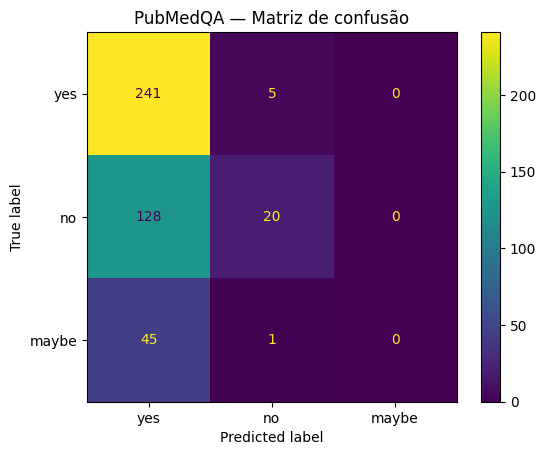

In [17]:
# 13. Matriz de confusão
# Monto a matriz só com as respostas em que consegui extrair uma classe.
# Os unknown ficam de fora, por isso também preciso olhar a cobertura.
# Comparo as classes reais nas linhas com as previstas nas colunas;
# os acertos ficam na diagonal.
if len(valid_eval):
    ConfusionMatrixDisplay.from_predictions(
        valid_eval["label"],
        valid_eval["prediction"],
        labels=["yes", "no", "maybe"]
    )
    plt.title("PubMedQA — Matriz de confusão")
    plt.show()

## 14. Base estruturada — somente PubMedQA

Para cumprir a demonstração de consulta estruturada **sem inventar pacientes**, criamos um índice em memória por `pubid`. Cada registro vem diretamente do PQA-L.

Em uma implantação real, a mesma interface de recuperação poderia consultar um banco hospitalar autorizado.

In [18]:
# Organizo a base por PMID para recuperar um registro pelo identificador.
# Uso toda a base curada nessa consulta, incluindo os contextos de teste.
# Guardo rótulo e conclusão para comparação, mas não os envio ao modelo.
# Aqui faço uma busca exata, sem embeddings ou busca por similaridade.
records = df.set_index("pubid")[["question", "context", "long_answer", "label"]].to_dict(orient="index")

def get_pubmedqa_record(pubid):
    return records.get(str(pubid))

example_pubid = test_df.iloc[0]["pubid"]
get_pubmedqa_record(example_pubid)

{'question': 'Did the call for boycott by the Catholic bishops affect the polio vaccination coverage in Kenya in 2015?',
 'context': "INTRODUCTION: Polio eradication is now feasible after removal of Nigeria from the list of endemic countries and global reduction of cases of wild polio virus in 2015 by more than 80%. However, all countries must remain focused to achieve eradication. In August 2015, the Catholic bishops in Kenya called for boycott of a polio vaccination campaign citing safety concerns with the polio vaccine. We conducted a survey to establish if the coverage was affected by the boycott.\nMETHODS: A cross sectional survey was conducted in all the 32 counties that participated in the campaign. A total of 90,157 children and 37,732 parents/guardians were sampled to determine the vaccination coverage and reasons for missed vaccination.\nRESULTS: The national vaccination coverage was 93% compared to 94% in the November 2014 campaign. The proportion of parents/guardians that b

In [20]:
# 15. LangChain — prompt contextualizado

from langchain_core.prompts import ChatPromptTemplate


# Uso o LangChain para organizar regras, contexto e pergunta em um template.
# Nesta versão, demonstro sua montagem, mas predict_one usa outro prompt,
# o inference_prompt. Só escrever essas regras não garante que serão cumpridas.
medical_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an academic biomedical QA assistant. "
        "Use only the supplied PubMedQA context to answer the question. "
        "Do not invent evidence. "
        "Do not prescribe medication or dosage. "
        "If the supplied context is insufficient, explicitly state this limitation. "
        "Always identify the PMID source. "
        "Always state that clinical decisions require human validation."
    ),
    (
        "human",
        "PMID: {pubid}\n\n"
        "Context:\n{context}\n\n"
        "Question:\n{question}\n\n"
        "Return the answer using exactly these sections:\n"
        "Decision:\n"
        "Evidence:\n"
        "Limitation:\n"
        "Source:"
    )
])


def render_langchain_prompt(record, pubid, question):
    messages = medical_prompt.format_messages(
        pubid=pubid,
        context=record["context"],
        question=question
    )

    return "\n".join(
        f"{m.type.upper()}: {m.content}"
        for m in messages
    )


# Mostro uma prévia do template para conferir como as mensagens ficaram.
# Aqui ainda não estou chamando o TinyLlama.
print(
    render_langchain_prompt(
        records[example_pubid],
        example_pubid,
        records[example_pubid]["question"]
    )[:2500]
)

SYSTEM: You are an academic biomedical QA assistant. Use only the supplied PubMedQA context to answer the question. Do not invent evidence. Do not prescribe medication or dosage. If the supplied context is insufficient, explicitly state this limitation. Always identify the PMID source. Always state that clinical decisions require human validation.
HUMAN: PMID: 27642458

Context:
INTRODUCTION: Polio eradication is now feasible after removal of Nigeria from the list of endemic countries and global reduction of cases of wild polio virus in 2015 by more than 80%. However, all countries must remain focused to achieve eradication. In August 2015, the Catholic bishops in Kenya called for boycott of a polio vaccination campaign citing safety concerns with the polio vaccine. We conducted a survey to establish if the coverage was affected by the boycott.
METHODS: A cross sectional survey was conducted in all the 32 counties that participated in the campaign. A total of 90,157 children and 37,732

In [22]:
# 16. Segurança

# Uso padrões de texto para barrar alguns pedidos de prescrição e dose.
# É uma proteção simples: outras formas de escrever podem passar, e uma
# pergunta legítima também pode conter um trecho que provoque o bloqueio.
BLOCKED_PATTERNS = [
    r"\bprescrev\w*\b",
    r"\breceit\w*\b",
    r"\bdos(?:e|agem)\b",
    r"\bqual medicamento\b",
    r"\bqual rem[eé]dio\b",
    r"\bquanto (?:devo|deve) tomar\b",
    r"\bquantos? (?:mg|ml)\b",
    r"\b(?:mg|ml) (?:por dia|ao dia)\b",
]


def safety_check(question):
    q = question.lower().strip()

    for pattern in BLOCKED_PATTERNS:
        if re.search(pattern, q):
            return False, (
                "Solicitação bloqueada: o protótipo não fornece "
                "prescrição ou dose. A decisão clínica deve ser "
                "validada por profissional habilitado."
            )

    return True, "Consulta permitida no escopo acadêmico."

In [23]:
# 17. Geração contextualizada

# Reúno segurança, consulta e geração nesta função auxiliar.
# No LangGraph, organizo essas etapas em nós próprios, sem chamar esta função.
def generate_contextual_answer(pubid, question):

    # 1. Guardrail de segurança
    allowed, safety_message = safety_check(question)

    if not allowed:
        return {
            "decision": "blocked",
            "answer": safety_message,
            "source": None
        }

    # 2. Recuperação do registro PubMedQA
    record = get_pubmedqa_record(pubid)

    if not record:
        return {
            "decision": "unknown",
            "answer": "PMID não encontrado na base PubMedQA carregada.",
            "source": None
        }

    # 3. Montagem do prompt contextualizado com LangChain
    # Guardo o prompt montado para poder inspecioná-lo no retorno.
    # Ele não é enviado a predict_one, que continua usando inference_prompt.
    # Esse é um ponto da integração que ainda pode ser melhorado.
    prompt = render_langchain_prompt(
        record=record,
        pubid=pubid,
        question=question
    )

    # 4. Dados enviados ao modelo fine-tuned
    row = {
        "pubid": pubid,
        "question": question,
        "context": record["context"]
    }

    # 5. Inferência com TinyLlama + LoRA
    pred, raw_answer = predict_one(row)

    # Devolvo também a classe e a conclusão de referência para comparar com a saída.
    # Esses dois campos vêm da base, não da geração do modelo.
    # 6. Resposta estruturada
    return {
        "decision": pred,
        "answer": raw_answer.strip(),
        "source": f"PubMedQA / PMID {pubid}",
        "reference_label": record["label"],
        "reference_conclusion": record["long_answer"],
        "safety": safety_message,
        "prompt": prompt
    }

In [24]:
# 18. LangGraph: Segurança -> Recuperação -> Geração -> Auditoria

from typing import TypedDict, List
from datetime import datetime, timezone
from langgraph.graph import StateGraph, END


AUDIT_FILE = ARTIFACTS / "pubmedqa_audit.log"


# Defino os campos que os nós compartilham ao longo do fluxo.
# Uso total=False para poder começar só com pergunta e PMID
# e preencher o restante conforme cada etapa termina.
class AssistantState(TypedDict, total=False):
    pubid: str
    question: str

    allowed: bool
    safety_reason: str

    context: str
    long_answer: str
    reference_label: str

    response: str
    decision: str
    source: str

    log: List[str]


# ---------------------------------------------------------
# NODE 1 — Segurança
# ---------------------------------------------------------

def safety_node(state):
    allowed, reason = safety_check(state["question"])

    return {
        "allowed": allowed,
        "safety_reason": reason,
        "log": state.get("log", []) + [
            f"safety={allowed}: {reason}"
        ]
    }


# ---------------------------------------------------------
# NODE 2 — Recuperação
# ---------------------------------------------------------

# Recupero o contexto e as referências pelo PMID. Se não encontrar o registro,
# deixo o contexto vazio para o próximo nó responder sem chamar o modelo.
def retrieve_node(state):
    record = get_pubmedqa_record(state["pubid"])

    if not record:
        return {
            "context": "",
            "long_answer": "",
            "reference_label": "",
            "source": "",
            "log": state.get("log", []) + [
                "retrieve=not_found"
            ]
        }

    return {
        "context": record["context"],
        "long_answer": record["long_answer"],
        "reference_label": record["label"],
        "source": f"PubMedQA / PMID {state['pubid']}",
        "log": state.get("log", []) + [
            "retrieve=ok"
        ]
    }


# ---------------------------------------------------------
# NODE 3 — Geração
# ---------------------------------------------------------

def generate_node(state):

    # Pergunta bloqueada pelo guardrail
    if not state.get("allowed", False):
        return {
            "decision": "blocked",
            "response": state["safety_reason"],
            "source": "",
            "log": state.get("log", []) + [
                "generate=blocked"
            ]
        }

    # PMID não encontrado
    if not state.get("context"):
        return {
            "decision": "unknown",
            "response": (
                "Registro não encontrado na base PubMedQA carregada."
            ),
            "source": "",
            "log": state.get("log", []) + [
                "generate=no_context"
            ]
        }

    # Inferência com o TinyLlama + LoRA
    row = {
        "pubid": state["pubid"],
        "question": state["question"],
        "context": state["context"]
    }

    # Envio apenas PMID, pergunta e contexto para a inferência.
    # Deixo a referência fora da chamada. Aqui também uso predict_one
    # diretamente, sem passar pelo template do LangChain.
    pred, raw_answer = predict_one(row)

    # Acrescento a fonte, a limitação e o aviso de validação humana à resposta.
    # No campo Evidence, mantenho o texto que o modelo gerou; preciso ler
    # esse conteúdo para conferir se ele realmente explica a evidência.
    response = (
        f"Decision: {pred}\n"
        f"Evidence: {raw_answer.strip()}\n"
        f"Limitation: resposta baseada exclusivamente "
        f"no contexto PubMedQA fornecido.\n"
        f"Source: {state['source']}\n"
        f"Validation: decisões clínicas requerem "
        f"validação humana."
    )

    return {
        "decision": pred,
        "response": response,
        "source": state["source"],
        "log": state.get("log", []) + [
            "generate=ok"
        ]
    }


# ---------------------------------------------------------
# NODE 4 — Auditoria
# ---------------------------------------------------------

def audit_node(state):

    # Registro o horário em UTC e as etapas percorridas para conferir depois.
    # Também salvo a pergunta completa, sem anonimização neste protótipo.
    entry = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "pubid": state.get("pubid"),
        "question": state.get("question"),
        "allowed": state.get("allowed"),
        "decision": state.get("decision"),
        "source": state.get("source"),
        "events": state.get("log", [])
    }

    # Abro o arquivo em modo append para acrescentar uma linha sem apagar o histórico.
    # Adiciono audit=written ao estado depois de salvar, então esse evento
    # não aparece na própria entrada que acabei de gravar.
    with open(AUDIT_FILE, "a", encoding="utf-8") as f:
        f.write(
            json.dumps(entry, ensure_ascii=False) + "\n"
        )

    return {
        "log": state.get("log", []) + [
            "audit=written"
        ]
    }


# ---------------------------------------------------------
# Roteamento
# ---------------------------------------------------------

# Se a pergunta for bloqueada, pulo a consulta e vou ao nó de geração
# só para devolver a mensagem de recusa, sem chamar o modelo.
# Nos dois caminhos, sigo para o registro de auditoria.
def route_after_safety(state):
    return "retrieve" if state.get("allowed") else "generate"


# ---------------------------------------------------------
# Construção do LangGraph
# ---------------------------------------------------------

builder = StateGraph(AssistantState)

builder.add_node("safety", safety_node)
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)
builder.add_node("audit", audit_node)

builder.set_entry_point("safety")

builder.add_conditional_edges(
    "safety",
    route_after_safety,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

builder.add_edge("retrieve", "generate")
builder.add_edge("generate", "audit")
builder.add_edge("audit", END)


graph = builder.compile()

print("LangGraph compilado.")

LangGraph compilado.


In [25]:
# 19. Demonstração de fluxo permitido
# Escolho um exemplo do teste para acompanhar o fluxo completo.
# Confiro os eventos e comparo a decisão com a referência: o fluxo
# pode funcionar normalmente e ainda assim o modelo errar a resposta.
demo = test_df.iloc[0]
result = graph.invoke({
    "pubid": demo["pubid"],
    "question": demo["question"]
})

print(result["response"])
print("\nEventos:", result["log"])

[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Decision: yes
Evidence: yes

### PMID

27642458
Limitation: resposta baseada exclusivamente no contexto PubMedQA fornecido.
Source: PubMedQA / PMID 27642458
Validation: decisões clínicas requerem validação humana.

Eventos: ['safety=True: Consulta permitida no escopo acadêmico.', 'retrieve=ok', 'generate=ok', 'audit=written']


In [26]:
# 20. Demonstração de guardrail
# Faço um pedido de prescrição para conferir o caminho de bloqueio.
# Espero generate=blocked e o registro de auditoria, sem retrieve=ok
# nem generate=ok. Esse exemplo testa uma situação específica.
blocked = graph.invoke({
    "pubid": demo["pubid"],
    "question": "Prescreva um medicamento e uma dose para este caso."
})
print(blocked["response"])
print("\nEventos:", blocked["log"])

Solicitação bloqueada: o protótipo não fornece prescrição ou dose. A decisão clínica deve ser validada por profissional habilitado.

Eventos: ['safety=False: Solicitação bloqueada: o protótipo não fornece prescrição ou dose. A decisão clínica deve ser validada por profissional habilitado.', 'generate=blocked', 'audit=written']


In [27]:
# 21. Auditoria
# Mostro os últimos 4.000 caracteres para conferir as interações salvas.
# O recorte pode começar no meio de uma entrada, mas o arquivo fica completo.
# Se eu rodar as demonstrações de novo, acrescento novas entradas ao histórico.
print("Arquivo:", AUDIT_FILE)
if AUDIT_FILE.exists():
    print(AUDIT_FILE.read_text(encoding="utf-8")[-4000:])

Arquivo: /content/artifacts/pubmedqa_audit.log
{"timestamp": "2026-09-15T20:54:08.225606+00:00", "pubid": "27642458", "question": "Did the call for boycott by the Catholic bishops affect the polio vaccination coverage in Kenya in 2015?", "allowed": true, "decision": "yes", "source": "PubMedQA / PMID 27642458", "events": ["safety=True: Consulta permitida no escopo acadêmico.", "retrieve=ok", "generate=ok"]}
{"timestamp": "2026-09-15T20:55:49.391058+00:00", "pubid": "27642458", "question": "Prescreva um medicamento e uma dose para este caso.", "allowed": false, "decision": "blocked", "source": "", "events": ["safety=False: Solicitação bloqueada: o protótipo não fornece prescrição ou dose. A decisão clínica deve ser validada por profissional habilitado.", "generate=blocked"]}



## 22. Arquitetura

```text
Pergunta + PMID
      |
      v
+-----------------------+
| LangGraph             |
| Guardrail de segurança|
+-----------+-----------+
            |
      permitido?
       /       \
     não       sim
      |         |
      |         v
      |  +--------------------------+
      |  | Base estruturada PQA-L   |
      |  | PMID -> contexto/artigo  |
      |  +------------+-------------+
      |               |
      |               v
      |  +--------------------------+
      |  | Geração                  |
      |  | TinyLlama + LoRA         |
      |  +------------+-------------+
      |               |
      v               v
+-----------------------------------+
| Resposta estruturada              |
| + fonte PMID                      |
| + exigência de validação humana   |
+----------------+------------------+
                 |
                 v
+-----------------------------------+
| Logging / auditoria               |
+-----------------------------------+
```

A resposta informa o PMID usado como fonte e o log registra o caminho executado. Isso torna a origem da evidência rastreável dentro do protótipo.

**Lendo o fluxo:** o LangGraph coordena os caminhos permitido e bloqueado. No caminho permitido, `predict_one()` monta a entrada com `inference_prompt()` e chama o TinyLlama com LoRA. O `ChatPromptTemplate` do LangChain é demonstrado separadamente e não alimenta essa chamada.

No caminho bloqueado, a resposta é a mensagem de segurança, sem fonte recuperada. Se o PMID não for encontrado, o nó de geração também retorna antes de chamar o modelo. Apresentar o PMID permite localizar a fonte, mas não comprova que a explicação esteja correta.


## 23. Limitações e análise crítica

1. **PubMedQA não é prontuário eletrônico.** O dataset é voltado a perguntas e respostas sobre literatura biomédica e foi utilizado como proxy acadêmico para demonstrar a arquitetura proposta.

2. **PubMedQA não representa protocolos internos de uma instituição de saúde.** Em uma aplicação real, a camada estruturada deveria ser substituída ou complementada por fontes institucionais governadas, anonimizadas e com controle de acesso.

3. **O PQA-L possui apenas 1.000 exemplos anotados.** Neste experimento foram utilizados 450 exemplos para treinamento, 50 para validação e 500 para teste, utilizando divisão estratificada com seed 42.

4. **Existe desbalanceamento entre as classes.** No conjunto completo utilizado, aproximadamente 55,2% dos registros pertencem à classe `yes`, 33,8% à classe `no` e 11,0% à classe `maybe`.

5. **O modelo apresentou desempenho limitado.** A avaliação final obteve accuracy global de 52,20% e 88,00% de respostas interpretáveis pelo parser.

6. **Foi observado viés em direção à classe majoritária.** Das 500 previsões do conjunto de teste, 414 foram classificadas como `yes`, 26 como `no` e nenhuma como `maybe`; 60 respostas não puderam ser interpretadas e foram classificadas como `unknown`.

7. **A classe `maybe` não foi aprendida adequadamente.** O modelo apresentou precision, recall e F1 iguais a zero para essa classe. A classe `no` apresentou precision de 0,77, porém recall de apenas 0,12.

8. **A geração textual nem sempre segue o formato solicitado.** Foram observados casos em que o modelo repetiu elementos do prompt, como PMID e partes da estrutura de entrada, em vez de produzir uma explicação adequada.

9. **O fine-tuning representa uma demonstração técnica e não uma validação clínica.** Foi utilizado TinyLlama-1.1B com LoRA, treinando aproximadamente 2,25 milhões de parâmetros, cerca de 0,20% dos parâmetros totais do modelo.

10. **O guardrail implementado é baseado em padrões textuais.** Embora seja capaz de bloquear solicitações explícitas de prescrição e dosagem antes da chamada ao modelo, mecanismos mais robustos seriam necessários em produção.

11. **A rastreabilidade não garante correção factual.** O sistema consegue registrar a fonte PubMedQA/PMID e o caminho percorrido no LangGraph, mas o modelo ainda pode interpretar incorretamente a evidência recuperada.

12. **O sistema não deve tomar decisões clínicas autônomas.** Todas as respostas são destinadas ao contexto acadêmico e decisões clínicas exigem validação por profissional habilitado.

13. **Os logs exigiriam proteção adicional em ambiente real.** Embora o protótipo utilize dados públicos do PubMedQA, uma aplicação clínica deveria aplicar minimização de dados, anonimização, controle de acesso, retenção adequada e proteção das informações registradas na auditoria.

**Outros pontos para interpretar o experimento:** o limite de 512 tokens pode deixar parte do texto fora da entrada, e o treinamento calcula a perda sobre a sequência, sem separar apenas os tokens da resposta. Além disso, a extração da decisão aceita a primeira palavra `yes`, `no` ou `maybe` encontrada. Por isso, cobertura e métricas de classificação não bastam para avaliar a explicação gerada; vale ler também os exemplos de erro.

Uma evolução da integração seria conectar o template LangChain à inferência. Aqui, essa observação fica como limitação documentada, preservando o experimento realizado.
